# **EyeCare – Smart Eye Disease Detection System**

EyeCare is an AI-powered automated eye disease detection system designed to assist in the early identification and screening of eye-related conditions through advanced image analysis and deep learning technology. It enables fast, non-invasive, and efficient detection of potential eye diseases from retinal or eye images, helping healthcare professionals improve diagnosis accuracy, reduce manual efforts, and support timely treatment decisions.

#**Install required libraries**

In [1]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 43.5 MB/s eta 0:00:00


##**Import Libraries**

In [2]:
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
from google.colab import files

import os, glob, yaml
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully.


##**Connect Roboflow Dataset of Eye Disease**

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="JsoNNfZp3TvBX4xO8L52")
project = rf.workspace("fabricdefect-g0o4o").project("eye-disease-yg5lp")
version = project.version(4)
dataset = version.download("yolov8")







print("Dataset downloaded at:", dataset.location)

print("Dataset downloaded successfully.")
print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Eye-disease-4 in yolov8:: 100%|██████████| 5311/5311 [00:00<00:00, 6705.76it/s]

Dataset downloaded at: /content/Eye-disease-4
Dataset downloaded successfully.
Dataset location: /content/Eye-disease-4


##**check Dataset Files**

In [4]:
dataset_path = dataset.location
data_yaml_path = os.path.join(dataset_path, "data.yaml")

print("Dataset path:", dataset_path)
print("data.yaml exists:", os.path.exists(data_yaml_path))

print("\nDataset folder content:")
for item in os.listdir(dataset_path):
    print("-", item)

Dataset path: /content/Eye-disease-4
data.yaml exists: True

Dataset folder content:
- test
- README.dataset.txt
- data.yaml
- README.roboflow.txt
- valid
- train


##**Read `data.yaml` and Class Names**

In [5]:
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

class_names = data_yaml.get("names", [])
print("\nClasses:", class_names)
print("Number of classes:", len(class_names))

{'names': ['Bacterial Conjunctivitis', 'Cataract', 'Chalazion', 'Conjunctivitis', 'Foreign Object', 'Hordeolum', 'Katarak', 'Normal', 'Pinguecula', 'Ptrigio-Pinguecula', 'Viral Conjunctivitis', 'cataract', 'normal', 'normal eye'], 'nc': 14, 'roboflow': {'license': 'CC BY 4.0', 'project': 'eye-disease-yg5lp', 'url': 'https://universe.roboflow.com/fabricdefect-g0o4o/eye-disease-yg5lp/dataset/4', 'version': 4, 'workspace': 'fabricdefect-g0o4o'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Classes: ['Bacterial Conjunctivitis', 'Cataract', 'Chalazion', 'Conjunctivitis', 'Foreign Object', 'Hordeolum', 'Katarak', 'Normal', 'Pinguecula', 'Ptrigio-Pinguecula', 'Viral Conjunctivitis', 'cataract', 'normal', 'normal eye']
Number of classes: 14


##**Count Images**

In [6]:
def count_images(folder):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    return sum(len(glob.glob(os.path.join(folder, ext))) for ext in exts)

train_img_dir = os.path.join(dataset_path, "train", "images")
valid_img_dir = os.path.join(dataset_path, "valid", "images")
test_img_dir = os.path.join(dataset_path, "test", "images")

counts = {
    "Train Images": count_images(train_img_dir),
    "Validation Images": count_images(valid_img_dir),
    "Test Images": count_images(test_img_dir)
}

pd.DataFrame([counts])

,Train Images,Validation Images,Test Images
0,2475,121,57


##**Generate preview of Sample Training Images**

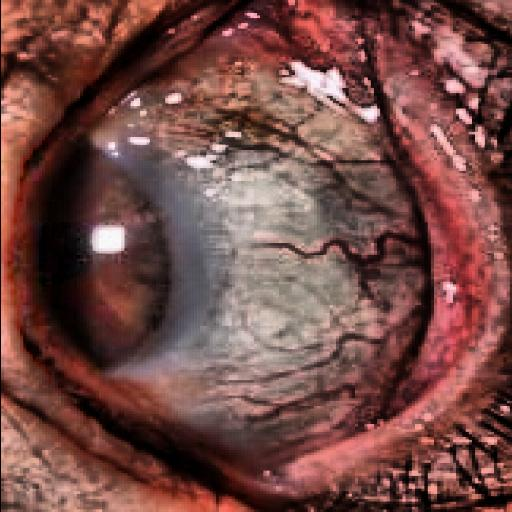

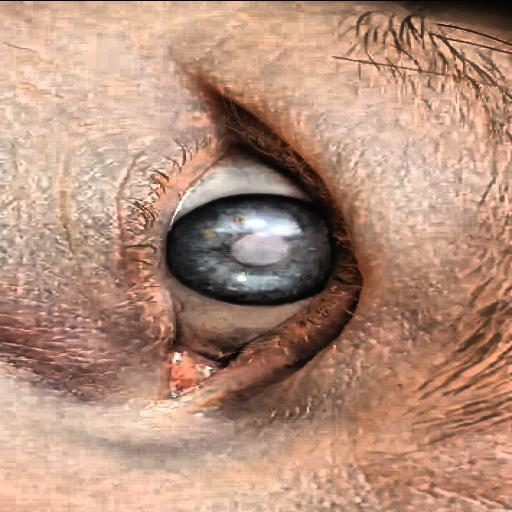

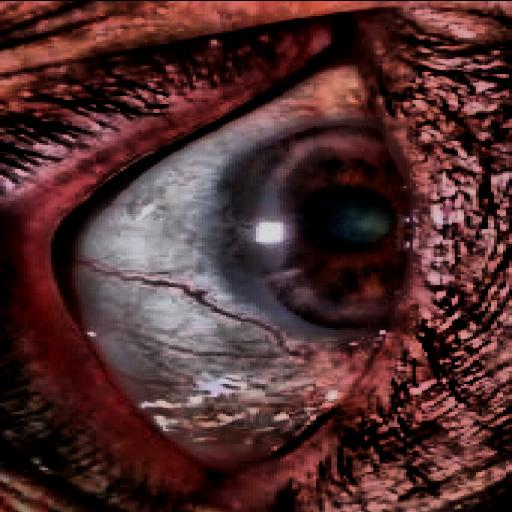

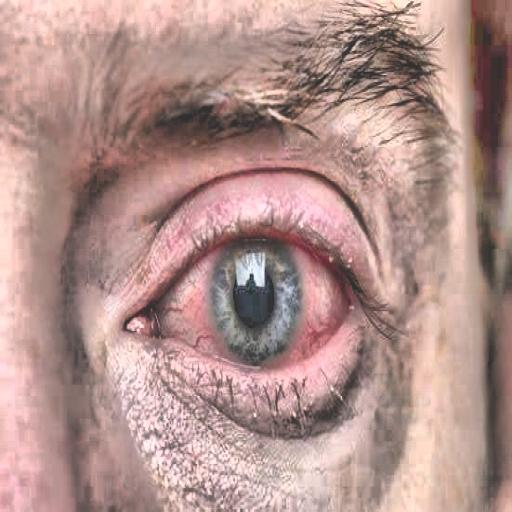

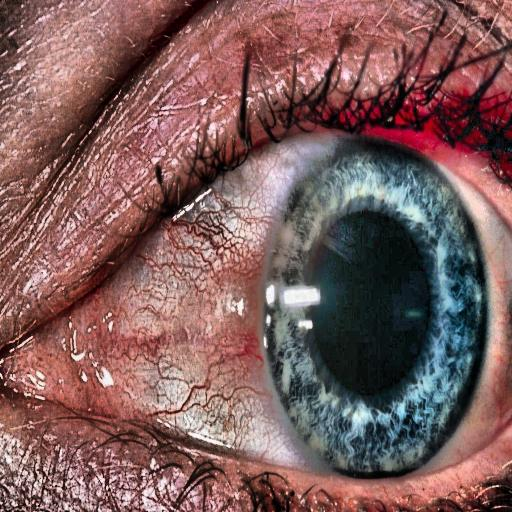

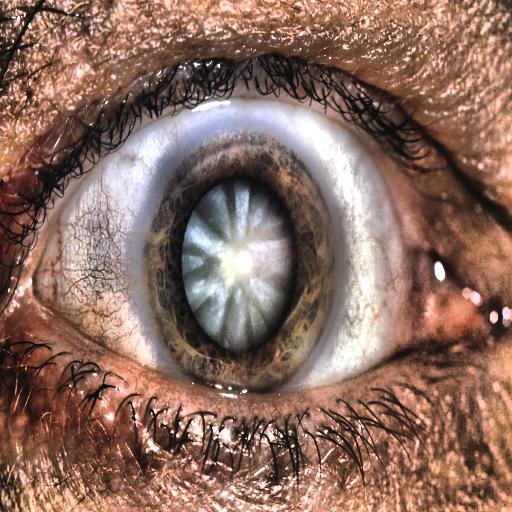

In [7]:
sample_images = glob.glob(os.path.join(train_img_dir, "*"))[:6]

for img in sample_images:
    display(Image(filename=img, width=400))

##**Load Pretrained YOLO Model**

In [8]:
model = YOLO("yolov8n.pt")
print("YOLOv8 nano model loaded successfully.")

YOLOv8 nano model loaded successfully.


##**Detect the possible disease**

In [9]:
results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=640,
    batch=8,
    name="eye_disease_detection"
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Eye-disease-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=eye_disease_detection, nbs=64, nms=False, opset=None, optimize=False, 

##**Display training results**

In [10]:
train_run_dir = "runs/detect/students_detection"

result_files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for file in result_files:
    path = os.path.join(train_run_dir, file)
    if os.path.exists(path):
        print("\n", file)
        display(Image(filename=path, width=800))
    else:
        print("Not found:", file)

Not found: results.png
Not found: confusion_matrix.png
Not found: PR_curve.png
Not found: F1_curve.png
Not found: P_curve.png
Not found: R_curve.png


##**Validate the trained model**

In [11]:
from ultralytics import YOLO
import glob
import os

# Find trained YOLO model automatically
model_files = glob.glob(
    "runs/detect/**/weights/best.pt",
    recursive=True
)

if len(model_files) == 0:
    print("No trained model found. Train the model first.")
else:

    best_model_path = model_files[0]

    print("Loading model:")
    print(best_model_path)

    best_model = YOLO(best_model_path)

    # Validate model
    metrics = best_model.val(
        data=data_yaml_path
    )

    print("Validation completed.")

Loading model:
runs/detect/eye_disease_detection/weights/best.pt
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1603.2±470.3 MB/s, size: 51.1 KB)
val: Scanning /content/Eye-disease-4/valid/labels.cache... 121 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 121/121 39.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 151. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.1it/s 3.9s
                   all        121        151       0.44      0.439      0.359      0.231
Bacterial Conjunctivitis          1          2      0.175        0

##**Testing on Roboflow Test Images**

In [12]:
test_results = best_model.predict(
    source=test_img_dir,
    conf=0.4,
    save=True,
    name="eye_disease_detection"
)

print("Prediction completed on test images.")


image 1/57 /content/Eye-disease-4/test/images/138_jpg.rf.b0664757637b2f718f349221f28bdcc0.jpg: 640x640 1 Chalazion, 27.3ms
image 2/57 /content/Eye-disease-4/test/images/140_jpg.rf.0ac1b6d0f3d99e339d3abfe2edeb7ebb.jpg: 640x640 1 Conjunctivitis, 12.8ms
image 3/57 /content/Eye-disease-4/test/images/160_jpg.rf.c3912b81464810990baf46535acfb4a5.jpg: 640x640 1 Conjunctivitis, 11.5ms
image 4/57 /content/Eye-disease-4/test/images/168_jpg.rf.f227f6abf6041ac0387893ed9e3dc89a.jpg: 640x640 (no detections), 24.6ms
image 5/57 /content/Eye-disease-4/test/images/203_jpg.rf.5fc85d4ea7e85383f4b4a9d5349c650f.jpg: 640x640 1 Conjunctivitis, 25.4ms
image 6/57 /content/Eye-disease-4/test/images/IMG_8170_JPG.rf.882981db4f3fa1537c13e9d099488679.jpg: 640x640 1 Bacterial Conjunctivitis, 8.9ms
image 7/57 /content/Eye-disease-4/test/images/IMG_8172_JPG.rf.621734dbe3c6b4bbc80ba959e441faef.jpg: 640x640 (no detections), 8.9ms
image 8/57 /content/Eye-disease-4/test/images/IMG_8176_JPG.rf.5bda7d542e812876aae8fbc0e25c57

##**Displaying test Prediction Images**

Number of predicted images: 57


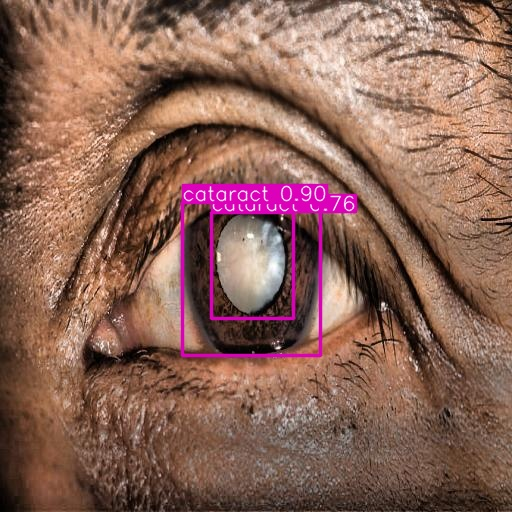

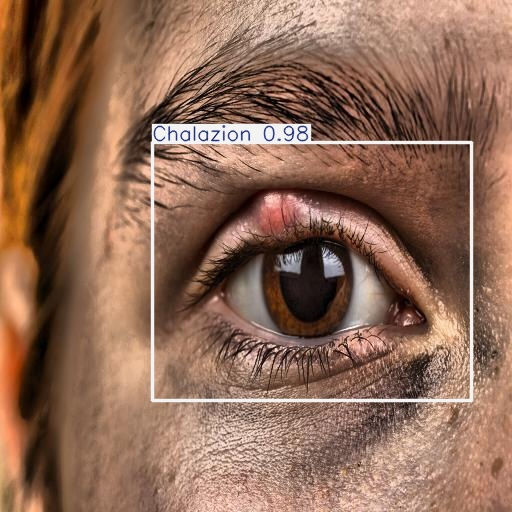

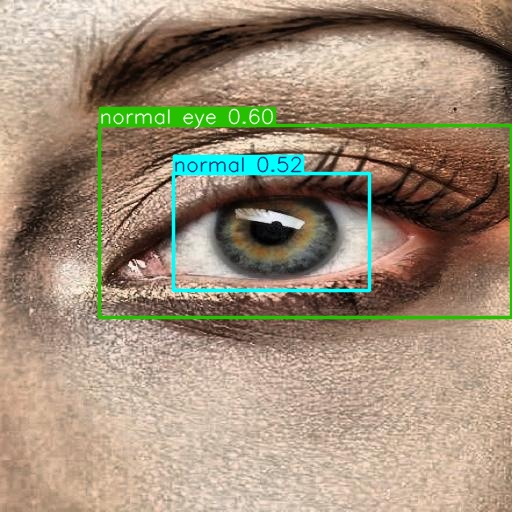

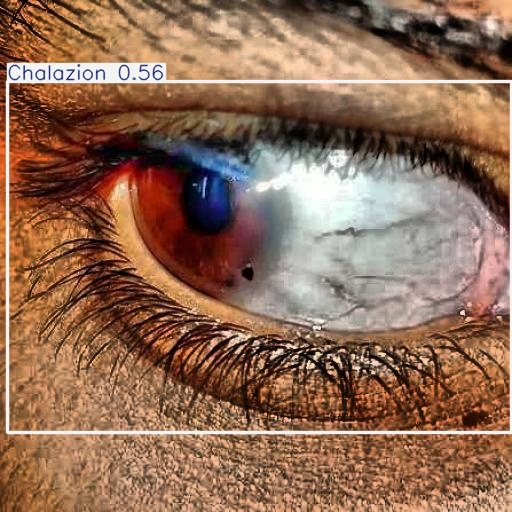

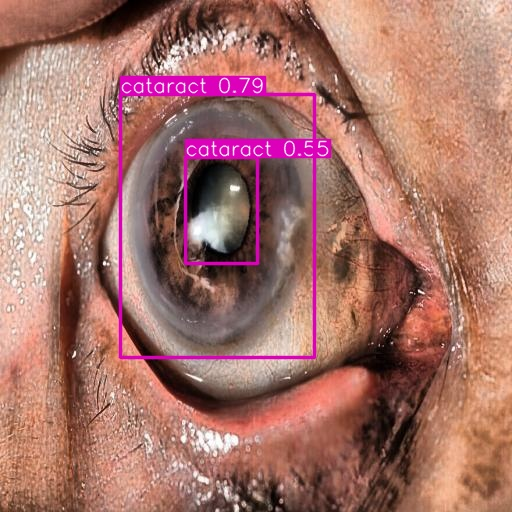

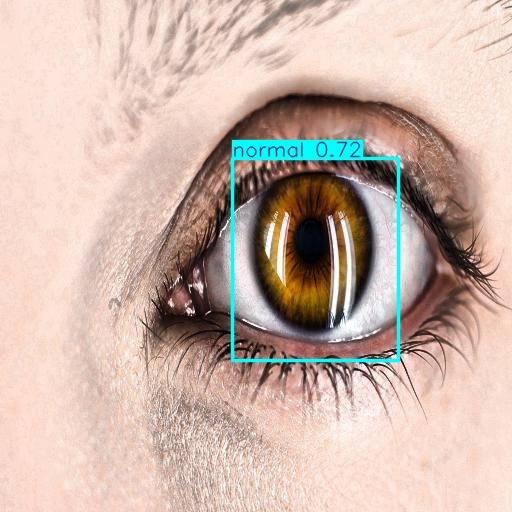

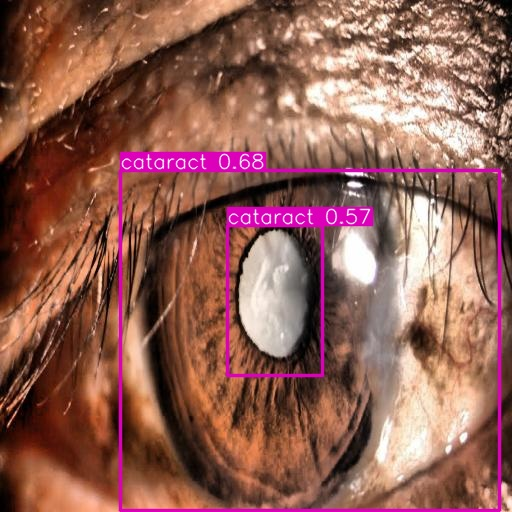

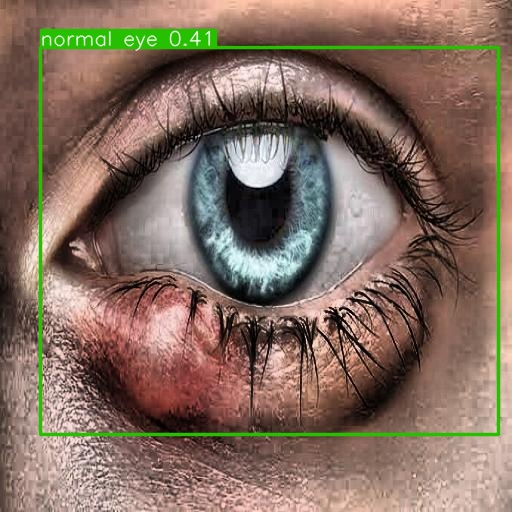

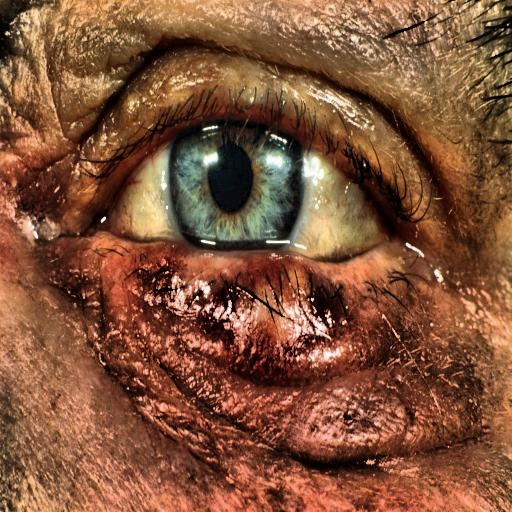

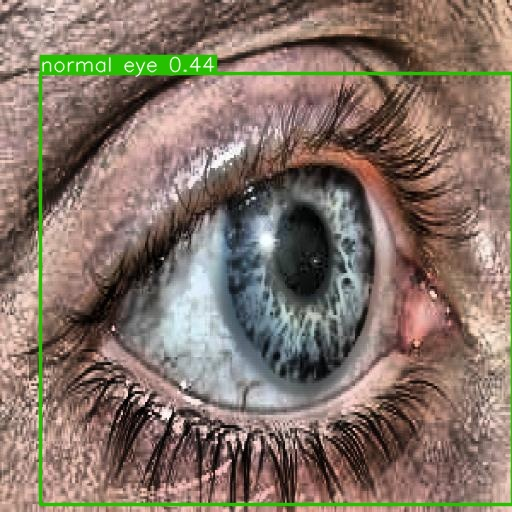

In [18]:
import os
import glob
from IPython.display import Image, display

# Path where YOLO saved predictions
prediction_dir = "runs/detect/eye_disease_detection-2"

# Get only image files
predicted_images = []

for ext in ["*.jpg", "*.jpeg", "*.png"]:
    predicted_images.extend(
        glob.glob(os.path.join(prediction_dir, ext))
    )

print("Number of predicted images:", len(predicted_images))

# Display first 10 predicted images
for img in predicted_images[:10]:
    display(Image(filename=img, width=600))

##**Testing on a New Uploaded Image**

In [65]:
uploaded = files.upload()
uploaded_image = list(uploaded.keys())[0]

results = best_model.predict(
    source=uploaded_image,
    conf=0.25,
    iou=0.4,  # Try lowering this (default is 0.7). Lower = fewer overlapping boxes.
    save=True,
    name="eye_disease_detection"
)


Saving catract eye.jpg to catract eye (1).jpg

image 1/1 /content/catract eye (1).jpg: 448x640 1 cataract, 10.3ms
Speed: 2.5ms preprocess, 10.3ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/eye_disease_detection-24


##**Displaying Uploaded Image Prediction**

Using latest result folder: runs/detect/eye_disease_detection-24


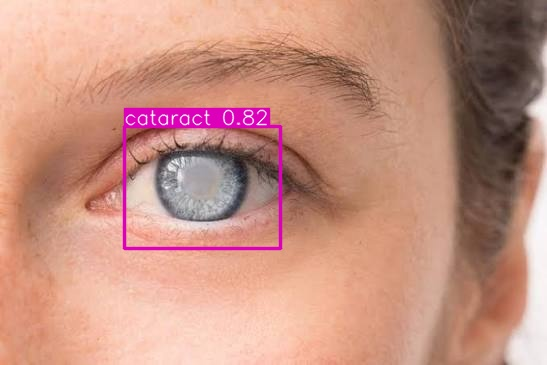

In [66]:
import os
import glob
from IPython.display import Image, display

# 1. Define the base directory where YOLO saves results
base_dir = "runs/detect"

# 2. Find all folders that match the pattern "eye_disease_detection*"
# We use glob to get all subfolders starting with your name
prediction_dirs = glob.glob(os.path.join(base_dir, "eye_disease_detection*"))

# 3. Sort the folders by creation time (or name) to get the most recent one
# Using max() with os.path.getmtime finds the folder modified most recently
latest_dir = max(prediction_dirs, key=os.path.getmtime)

print(f"Using latest result folder: {latest_dir}")

# 4. Grab the images from that folder
uploaded_pred_images = glob.glob(os.path.join(latest_dir, "*"))

for img in uploaded_pred_images:
    display(Image(filename=img, width=700))

##**Extract Detected Object Names and Confidence Scores**


In [67]:
# Update your prediction call to be more lenient
single_result = best_model.predict(
    source=uploaded_image,
    conf=0.25,  # Lowered to 0.25 to capture the 0.32 detection
    save=True,
    name="eye_disease_detection"
)

# Now your existing detection logic will work:
detections = []
for result in single_result:
    names = result.names
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = names[cls_id]

        detections.append({
            "Detected Object": label,
            "Confidence Score": round(conf, 3)
        })

if len(detections) == 0:
    print("No Disease Detected.")
else:
    import pandas as pd
    display(pd.DataFrame(detections))


image 1/1 /content/catract eye (1).jpg: 448x640 1 cataract, 9.2ms
Speed: 3.4ms preprocess, 9.2ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/eye_disease_detection-25


,Detected Object,Confidence Score
0,cataract,0.818


In [68]:
from google.colab import files
files.download("runs/detect/eye_disease_detection/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>